# ZIF-8 Membrane Quality Prediction — All Models (SMOTE Inside CV)

This notebook is identical to `zif8_all_models.ipynb` except **SMOTE is applied inside cross-validation folds** using `imblearn.pipeline.Pipeline`, eliminating data leakage.

**Key difference from the original notebook:**
- ❌ Original: SMOTE applied to entire dataset BEFORE splitting → data leakage
- ✅ This notebook: SMOTE applied ONLY to training fold inside each CV iteration → no leakage

**Models included (13 total):**
- From `zif8_ml_analysis.py`: k-NN (k=1,3,5), Random Forest (100), Decision Tree, ZeroR
- From `train_all_models.ipynb` (adapted to classifiers): Logistic Regression, SVC, XGBClassifier, LGBMClassifier, CatBoostClassifier
- Bonus: Gradient Boosting, MLP (Neural Network)

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score,
    precision_score, recall_score,
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # NOT sklearn.pipeline!
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# === Strictly follow zif8_ml_analysis.py: WEKA uses seed=1 by default ===
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
All libraries imported successfully!


## 2. Data Loading & Preprocessing

**Strictly follows `load_and_prepare_data()` from `zif8_ml_analysis.py`:**
- LabelEncoder for categorical columns (tree-based methods)
- OneHotEncoder (sparse_output=False, drop=None) for distance-based methods
- Separate feature matrices for different model types

In [ ]:
# Load dataset
df = pd.read_csv('zif8_synthesis_data.csv')

# Define features and target (same as zif8_ml_analysis.py)
feature_cols = ['Solvent_1', 'Solvent_2', 'Ratio', 'Temperature', 'Duration']
target_col = 'Quality'

# === Label Encoding (for tree-based methods) ===
encoders = {}
df_encoded = df.copy()

for col in ['Solvent_1', 'Solvent_2', 'Quality']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df_encoded[feature_cols].values
y = df_encoded[target_col].values

# === One-Hot Encoding (for distance-based methods: k-NN, SVC, Logistic Regression) ===
# This matches WEKA's handling of nominal attributes
cat_cols = ['Solvent_1', 'Solvent_2']
num_cols = ['Ratio', 'Temperature', 'Duration']

ohe = OneHotEncoder(sparse_output=False, drop=None)
cat_encoded = ohe.fit_transform(df[cat_cols])

cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
X_onehot = np.hstack([cat_encoded, df[num_cols].values])
feature_names_onehot = cat_feature_names + num_cols

encoders['onehot'] = ohe

# === Dataset Summary ===
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
print(f'Total instances: {len(df)}')
print(f'Features: {feature_cols}')
print(f'One-hot encoded features: {len(feature_names_onehot)}')
print(f'\nClass distribution:')
print(df['Quality'].value_counts())
print(f"Class ratio: {df['Quality'].value_counts()['High'] / df['Quality'].value_counts()['Low']:.2f}:1")
print(f'\nSolvent_1 distribution:')
print(df['Solvent_1'].value_counts())
print(f'\nLabel encoding mapping:')
for col_name, enc in encoders.items():
    if col_name != 'onehot':
        print(f'  {col_name}: {dict(zip(enc.classes_, enc.transform(enc.classes_)))}')

DATASET SUMMARY
Total instances: 68
Features: ['Solvent_1', 'Solvent_2', 'Ratio', 'Temperature', 'Duration']
One-hot encoded features: 10

Class distribution:
Quality
High    52
Low     16
Name: count, dtype: int64
Class ratio: 3.25:1

Solvent_1 distribution:
Solvent_1
MeOH    48
EtOH    10
H2O      6
DMF      4
Name: count, dtype: int64

Label encoding mapping:
  Solvent_1: {'DMF': np.int64(0), 'EtOH': np.int64(1), 'H2O': np.int64(2), 'MeOH': np.int64(3)}
  Solvent_2: {'EtOH': np.int64(0), 'H2O': np.int64(1), 'MeOH': np.int64(2)}
  Quality: {'High': np.int64(0), 'Low': np.int64(1)}


## 3. Scaling (Without SMOTE)

**For models WITHOUT SMOTE**, scaling is applied the same way as `zif8_ml_analysis.py`.

**For models WITH SMOTE**, scaling is handled INSIDE the pipeline per CV fold (see Section 6).

No standalone SMOTE is applied here — that's the key difference from the original notebook.

In [ ]:
# === Scaling for non-SMOTE models (same as zif8_ml_analysis.py) ===

# MinMaxScaler for original data (matches WEKA's default for IBk/k-NN)
minmax_scaler = MinMaxScaler()
X_onehot_minmax = minmax_scaler.fit_transform(X_onehot)

# StandardScaler for original one-hot data (for SVC, Logistic Regression, MLP)
std_scaler_orig = StandardScaler()
X_onehot_std = std_scaler_orig.fit_transform(X_onehot)

print('Scaling applied for non-SMOTE models:')
print('  - MinMaxScaler on one-hot data (for k-NN, matching WEKA)')
print('  - StandardScaler on one-hot data (for SVC, Logistic Regression, MLP)')
print()
print('NOTE: For SMOTE models, scaling + SMOTE are applied INSIDE each CV fold')
print('      via imblearn.pipeline.Pipeline to prevent data leakage.')

Scaling applied for non-SMOTE models:
  - MinMaxScaler on one-hot data (for k-NN, matching WEKA)
  - StandardScaler on one-hot data (for SVC, Logistic Regression, MLP)

NOTE: For SMOTE models, scaling + SMOTE are applied INSIDE each CV fold
      via imblearn.pipeline.Pipeline to prevent data leakage.



















 dfkjfvnjkdfvoekkmfkldmvegjoierjgfvknkdjfnvsdj;nti





 ## 4. Evaluation Function

**Same evaluation function as the original notebook:**
- 10-fold StratifiedKFold with `shuffle=True`, `random_state=1`
- `cross_val_predict` for predictions and probabilities
- Works with both plain classifiers AND imblearn Pipelines
- Metrics: Accuracy, Kappa, Recall, Precision, F1, ROC-AUC, R², MAE, RMSE, MAPE

In [ ]:
def evaluate_classifier(clf, X_input, y_input, cv=10, name='Classifier'):
    """
    Evaluate a classifier (or pipeline) using stratified k-fold cross-validation.
    Works with both plain classifiers and imblearn Pipelines.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    print(f"\n{name} | n_splits = {skf.get_n_splits()}")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_input, y_input), start=1):
        print(f"Fold {fold}: train={len(train_idx)}, test={len(test_idx)}")

    # Get cross-validated predictions
    y_pred = cross_val_predict(clf, X_input, y_input, cv=skf)

    # Get predicted probabilities
    try:
        y_proba = cross_val_predict(clf, X_input, y_input, cv=skf, method='predict_proba')
        y_proba_positive = y_proba[:, 1]  # probability of class 1 (Low)
        roc_auc = roc_auc_score(y_input, y_proba_positive)
    except Exception:
        y_proba = None
        y_proba_positive = y_pred.astype(float)
        try:
            roc_auc = roc_auc_score(y_input, y_proba_positive)
        except Exception:
            roc_auc = np.nan

    # === Metrics ===
    accuracy = accuracy_score(y_input, y_pred)
    kappa = cohen_kappa_score(y_input, y_pred)

    precision_low = precision_score(y_input, y_pred, pos_label=1, zero_division=0)
    recall_low = recall_score(y_input, y_pred, pos_label=1, zero_division=0)
    f1_low = f1_score(y_input, y_pred, pos_label=1, zero_division=0)

    precision_high = precision_score(y_input, y_pred, pos_label=0, zero_division=0)
    recall_high = recall_score(y_input, y_pred, pos_label=0, zero_division=0)
    f1_high = f1_score(y_input, y_pred, pos_label=0, zero_division=0)

    cm = confusion_matrix(y_input, y_pred)

    # R2, MAE, RMSE, MAPE on predicted probabilities
    r2 = r2_score(y_input, y_proba_positive)
    mae = mean_absolute_error(y_input, y_proba_positive)
    rmse = np.sqrt(mean_squared_error(y_input, y_proba_positive))

    mask = y_input != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_input[mask] - y_proba_positive[mask]) / y_input[mask])) * 100
    else:
        mape = np.nan

    results = {
        'name': name,
        'accuracy': accuracy,
        'kappa': kappa,
        'recall_high': recall_high,
        'recall_low': recall_low,
        'precision_high': precision_high,
        'precision_low': precision_low,
        'f1_high': f1_high,
        'f1_low': f1_low,
        'roc_auc': roc_auc,
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    return results


def print_results(results):
    """Print formatted results for a classifier."""
    print(f"\n{results['name']}")
    print('-' * 45)
    print(f"Accuracy:        {results['accuracy']*100:.2f}%")
    print(f"Kappa:           {results['kappa']:.3f}")
    print(f"Recall (High):   {results['recall_high']*100:.1f}%")
    print(f"Recall (Low):    {results['recall_low']*100:.1f}%")
    print(f"Precision (Low): {results['precision_low']*100:.1f}%")
    print(f"F1-Score (Low):  {results['f1_low']:.3f}")
    print(f"ROC-AUC:         {results['roc_auc']:.3f}")
    print(f"R² Score:        {results['r2']:.3f}")
    print(f"MAE:             {results['mae']:.3f}")
    print(f"RMSE:            {results['rmse']:.3f}")
    print(f"MAPE:            {results['mape']:.2f}%")
    print(f"\nConfusion Matrix:")
    print(results['confusion_matrix'])


print('Evaluation functions defined!')

Evaluation functions defined!


## 5. All Models — Without SMOTE (Original Dataset)

**Identical to the original notebook** — no SMOTE applied.

In [ ]:
print('=' * 60)
print('CLASSIFIER COMPARISON — WITHOUT SMOTE')
print('=' * 60)

classifiers_original = [
    # --- From zif8_ml_analysis.py ---
    (KNeighborsClassifier(n_neighbors=1), X_onehot_minmax, 'k-NN (k=1)'),
    (KNeighborsClassifier(n_neighbors=3), X_onehot_minmax, 'k-NN (k=3)'),
    (KNeighborsClassifier(n_neighbors=5), X_onehot_minmax, 'k-NN (k=5)'),
    (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), X, 'Random Forest (100)'),
    (DecisionTreeClassifier(random_state=RANDOM_STATE), X, 'Decision Tree'),
    (DummyClassifier(strategy='most_frequent'), X, 'ZeroR (baseline)'),

    # --- From train_all_models.ipynb (adapted to classifiers) ---
    (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_onehot_std, 'Logistic Regression'),
    (SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_STATE), X_onehot_std, 'SVC (RBF)'),
    (XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                   random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss',
                   use_label_encoder=False), X, 'XGBoost'),
    (LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                    random_state=RANDOM_STATE, verbosity=-1), X, 'LightGBM'),
    (CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                        random_state=RANDOM_STATE, verbose=0), X, 'CatBoost'),

    # --- Bonus classifiers ---
    (GradientBoostingClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                random_state=RANDOM_STATE), X, 'Gradient Boosting'),
    (MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=RANDOM_STATE), X_onehot_std, 'MLP (Neural Network)'),
]

# Evaluate all models
all_results_original = []
for clf, X_input, name in classifiers_original:
    results = evaluate_classifier(clf, X_input, y, cv=10, name=name)
    all_results_original.append(results)
    print_results(results)

print(f'\n=== {len(all_results_original)} models evaluated without SMOTE ===')

CLASSIFIER COMPARISON — WITHOUT SMOTE

k-NN (k=1) | n_splits = 10
Fold 1: train=61, test=7
Fold 2: train=61, test=7
Fold 3: train=61, test=7
Fold 4: train=61, test=7
Fold 5: train=61, test=7
Fold 6: train=61, test=7
Fold 7: train=61, test=7
Fold 8: train=61, test=7
Fold 9: train=62, test=6
Fold 10: train=62, test=6

k-NN (k=1)
---------------------------------------------
Accuracy:        92.65%
Kappa:           0.781
Recall (High):   98.1%
Recall (Low):    75.0%
Precision (Low): 92.3%
F1-Score (Low):  0.828
ROC-AUC:         0.865
R² Score:        0.591
MAE:             0.074
RMSE:            0.271
MAPE:            25.00%

Confusion Matrix:
[[51  1]
 [ 4 12]]

k-NN (k=3) | n_splits = 10
Fold 1: train=61, test=7
Fold 2: train=61, test=7
Fold 3: train=61, test=7
Fold 4: train=61, test=7
Fold 5: train=61, test=7
Fold 6: train=61, test=7
Fold 7: train=61, test=7
Fold 8: train=61, test=7
Fold 9: train=62, test=6
Fold 10: train=62, test=6

k-NN (k=3)
-----------------------------------------

## 6. All Models — With SMOTE Inside CV (No Data Leakage)

**KEY DIFFERENCE: SMOTE is applied INSIDE each CV fold using `imblearn.pipeline.Pipeline`.**

For each fold:
1. Split data into train/test
2. Apply Scaler (if needed) to training data only
3. Apply SMOTE to training data only
4. Train classifier on SMOTE-augmented training data
5. Predict on UNTOUCHED test data

This prevents synthetic SMOTE samples from leaking into the test fold.

In [ ]:
print('=' * 60)
print('CLASSIFIER COMPARISON — SMOTE INSIDE CV (NO LEAKAGE)')
print('=' * 60)

smote = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)

# Each entry: (pipeline, X_data, name)
# Pipelines include: [optional scaler] -> SMOTE -> classifier
# IMPORTANT: use ORIGINAL (unscaled, un-SMOTEd) data — pipeline handles everything

classifiers_smote = [
    # --- k-NN: MinMaxScaler -> SMOTE -> k-NN (uses one-hot data) ---
    (ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', KNeighborsClassifier(n_neighbors=1))
    ]), X_onehot, 'k-NN (k=1) + SMOTE'),

    (ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', KNeighborsClassifier(n_neighbors=3))
    ]), X_onehot, 'k-NN (k=3) + SMOTE'),

    (ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]), X_onehot, 'k-NN (k=5) + SMOTE'),

    # --- Tree-based: SMOTE -> classifier (no scaler needed, label-encoded data) ---
    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ]), X, 'Random Forest (100) + SMOTE'),

    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]), X, 'Decision Tree + SMOTE'),

    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', DummyClassifier(strategy='most_frequent'))
    ]), X, 'ZeroR (baseline) + SMOTE'),

    # --- Distance-based: StandardScaler -> SMOTE -> classifier (one-hot data) ---
    (ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]), X_onehot, 'Logistic Regression + SMOTE'),

    (ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_STATE))
    ]), X_onehot, 'SVC (RBF) + SMOTE'),

    # --- Boosting: SMOTE -> classifier (label-encoded, no scaler) ---
    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss',
                              use_label_encoder=False))
    ]), X, 'XGBoost + SMOTE'),

    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                               random_state=RANDOM_STATE, verbosity=-1))
    ]), X, 'LightGBM + SMOTE'),

    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                                   random_state=RANDOM_STATE, verbose=0))
    ]), X, 'CatBoost + SMOTE'),

    (ImbPipeline([
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                           random_state=RANDOM_STATE))
    ]), X, 'Gradient Boosting + SMOTE'),

    # --- MLP: StandardScaler -> SMOTE -> MLP (one-hot data) ---
    (ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=RANDOM_STATE))
    ]), X_onehot, 'MLP (Neural Network) + SMOTE'),
]

# Evaluate all SMOTE pipelines on ORIGINAL data (pipeline handles SMOTE per fold)
all_results_smote = []
for pipe, X_input, name in classifiers_smote:
    results = evaluate_classifier(pipe, X_input, y, cv=10, name=name)
    all_results_smote.append(results)
    print_results(results)

print(f'\n=== {len(all_results_smote)} models evaluated with SMOTE inside CV ===')

CLASSIFIER COMPARISON — SMOTE INSIDE CV (NO LEAKAGE)

k-NN (k=1) + SMOTE | n_splits = 10
Fold 1: train=61, test=7
Fold 2: train=61, test=7
Fold 3: train=61, test=7
Fold 4: train=61, test=7
Fold 5: train=61, test=7
Fold 6: train=61, test=7
Fold 7: train=61, test=7
Fold 8: train=61, test=7
Fold 9: train=62, test=6
Fold 10: train=62, test=6

k-NN (k=1) + SMOTE
---------------------------------------------
Accuracy:        89.71%
Kappa:           0.720
Recall (High):   92.3%
Recall (Low):    81.2%
Precision (Low): 76.5%
F1-Score (Low):  0.788
ROC-AUC:         0.868
R² Score:        0.428
MAE:             0.103
RMSE:            0.321
MAPE:            18.75%

Confusion Matrix:
[[48  4]
 [ 3 13]]

k-NN (k=3) + SMOTE | n_splits = 10
Fold 1: train=61, test=7
Fold 2: train=61, test=7
Fold 3: train=61, test=7
Fold 4: train=61, test=7
Fold 5: train=61, test=7
Fold 6: train=61, test=7
Fold 7: train=61, test=7
Fold 8: train=61, test=7
Fold 9: train=62, test=6
Fold 10: train=62, test=6

k-NN (k=3) + 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 7. Summary Table & CSV Export

In [ ]:
def create_summary_table(all_results, dataset_label='Original'):
    """Create a summary DataFrame from results list."""
    summary_data = []
    for r in all_results:
        summary_data.append({
            'Classifier': r['name'],
            'Dataset': dataset_label,
            'Accuracy (%)': round(r['accuracy'] * 100, 2),
            'Kappa': round(r['kappa'], 3),
            'Recall High (%)': round(r['recall_high'] * 100, 1),
            'Recall Low (%)': round(r['recall_low'] * 100, 1),
            'Precision High (%)': round(r['precision_high'] * 100, 1),
            'Precision Low (%)': round(r['precision_low'] * 100, 1),
            'F1 High': round(r['f1_high'], 3),
            'F1 Low': round(r['f1_low'], 3),
            'ROC-AUC': round(r['roc_auc'], 3),
            'R2': round(r['r2'], 3),
            'MAE': round(r['mae'], 3),
            'RMSE': round(r['rmse'], 3),
            'MAPE (%)': round(r['mape'], 2),
        })
    return pd.DataFrame(summary_data)


# Create summary tables
df_original = create_summary_table(all_results_original, 'Original')
df_smote = create_summary_table(all_results_smote, 'SMOTE_inside_CV')

# Combine into one DataFrame
df_all = pd.concat([df_original, df_smote], ignore_index=True)

# Display
print('=' * 80)
print('SUMMARY — WITHOUT SMOTE')
print('=' * 80)
print(df_original.to_string(index=False))

print('\n' + '=' * 80)
print('SUMMARY — SMOTE INSIDE CV (NO LEAKAGE)')
print('=' * 80)
print(df_smote.to_string(index=False))

# Save to CSV
df_all.to_csv('zif8_smote_inside_cv_comparison.csv', index=False)
print(f'\n✅ Results saved to zif8_smote_inside_cv_comparison.csv ({len(df_all)} rows)')

SUMMARY — WITHOUT SMOTE
          Classifier  Dataset  Accuracy (%)  Kappa  Recall High (%)  Recall Low (%)  Precision High (%)  Precision Low (%)  F1 High  F1 Low  ROC-AUC     R2   MAE  RMSE  MAPE (%)
          k-NN (k=1) Original         92.65  0.781             98.1            75.0                92.7               92.3    0.953   0.828    0.865  0.591 0.074 0.271     25.00
          k-NN (k=3) Original         91.18  0.744             96.2            75.0                92.6               85.7    0.943   0.800    0.837  0.455 0.137 0.313     25.00
          k-NN (k=5) Original         91.18  0.744             96.2            75.0                92.6               85.7    0.943   0.800    0.900  0.598 0.126 0.269     23.75
 Random Forest (100) Original         92.65  0.781             98.1            75.0                92.7               92.3    0.953   0.828    0.889  0.522 0.183 0.293     38.88
       Decision Tree Original         86.76  0.588             96.2            56.2   

## 8. Visualization — 4-Panel Bar Chart

Horizontal bar chart comparing all models across 4 key metrics:
- Overall Accuracy
- Kappa Coefficient
- Minor Class Detection (Recall Low)
- ROC Area Under Curve

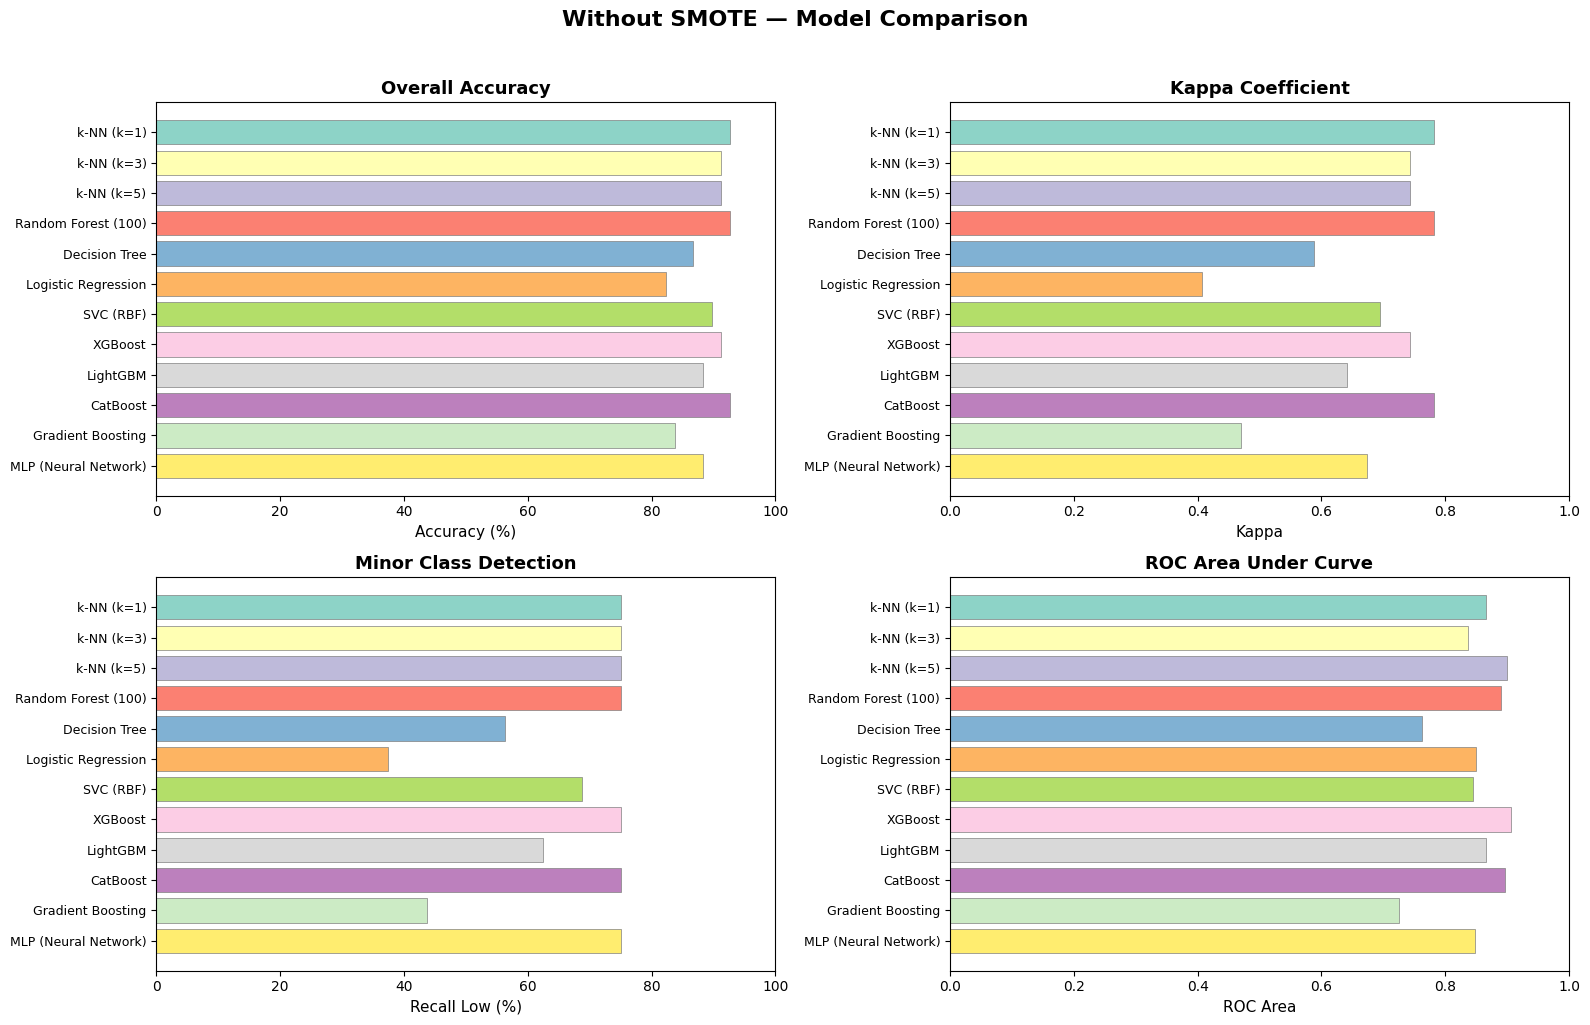

Saved: without_smote_—_4panel_comparison.png


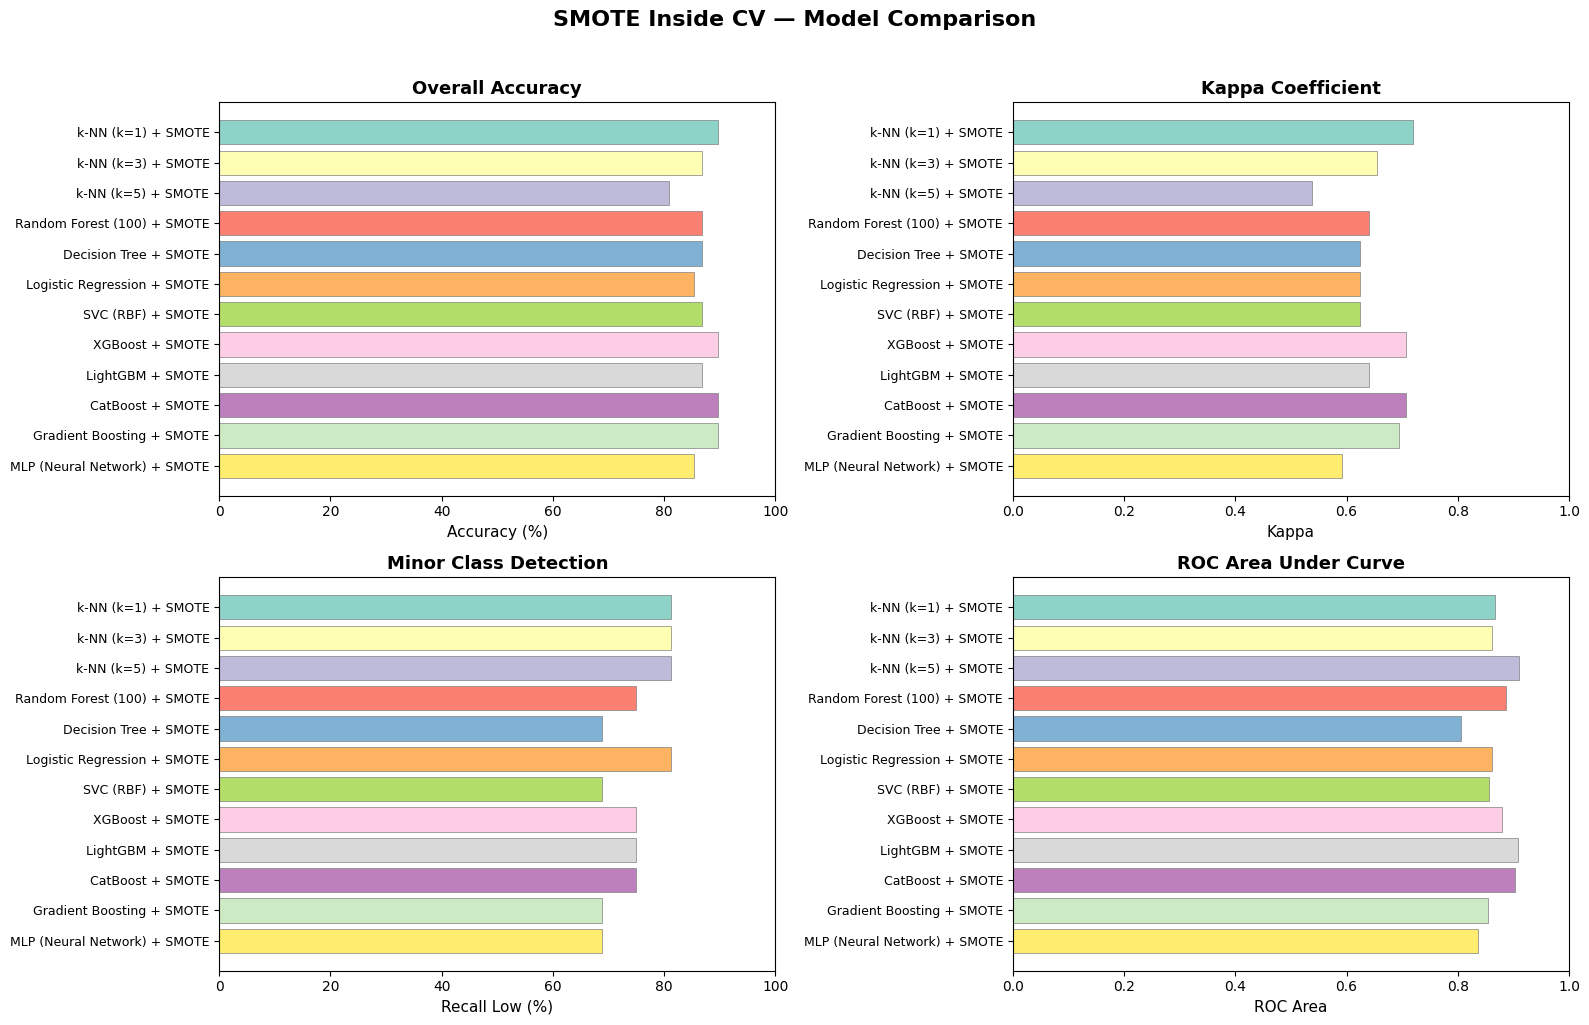

Saved: smote_inside_cv_—_4panel_comparison.png


In [ ]:
def plot_4panel_barchart(results_list, title_prefix=''):
    """
    Plot 4-panel horizontal bar chart matching the reference style.
    """
    results_filtered = [r for r in results_list if 'ZeroR' not in r['name']]

    names = [r['name'] for r in results_filtered]
    accuracies = [r['accuracy'] * 100 for r in results_filtered]
    kappas = [r['kappa'] for r in results_filtered]
    recall_lows = [r['recall_low'] * 100 for r in results_filtered]
    roc_aucs = [r['roc_auc'] for r in results_filtered]

    colors = plt.cm.Set3(np.linspace(0, 1, len(names)))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title_prefix}Model Comparison', fontsize=16, fontweight='bold', y=1.02)

    axes[0, 0].barh(names, accuracies, color=colors, edgecolor='grey', linewidth=0.5)
    axes[0, 0].set_xlabel('Accuracy (%)', fontsize=11)
    axes[0, 0].set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlim(0, 100)

    axes[0, 1].barh(names, kappas, color=colors, edgecolor='grey', linewidth=0.5)
    axes[0, 1].set_xlabel('Kappa', fontsize=11)
    axes[0, 1].set_title('Kappa Coefficient', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlim(0, 1.0)

    axes[1, 0].barh(names, recall_lows, color=colors, edgecolor='grey', linewidth=0.5)
    axes[1, 0].set_xlabel('Recall Low (%)', fontsize=11)
    axes[1, 0].set_title('Minor Class Detection', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlim(0, 100)

    axes[1, 1].barh(names, roc_aucs, color=colors, edgecolor='grey', linewidth=0.5)
    axes[1, 1].set_xlabel('ROC Area', fontsize=11)
    axes[1, 1].set_title('ROC Area Under Curve', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlim(0, 1.0)

    for ax in axes.flat:
        ax.tick_params(axis='y', labelsize=9)
        ax.invert_yaxis()

    plt.tight_layout()
    filename = f'{title_prefix.strip().replace(" ", "_").lower() if title_prefix else "original"}_4panel_comparison.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


plot_4panel_barchart(all_results_original, title_prefix='Without SMOTE — ')
plot_4panel_barchart(all_results_smote, title_prefix='SMOTE Inside CV — ')

## 9. Visualization — Confusion Matrix Grid

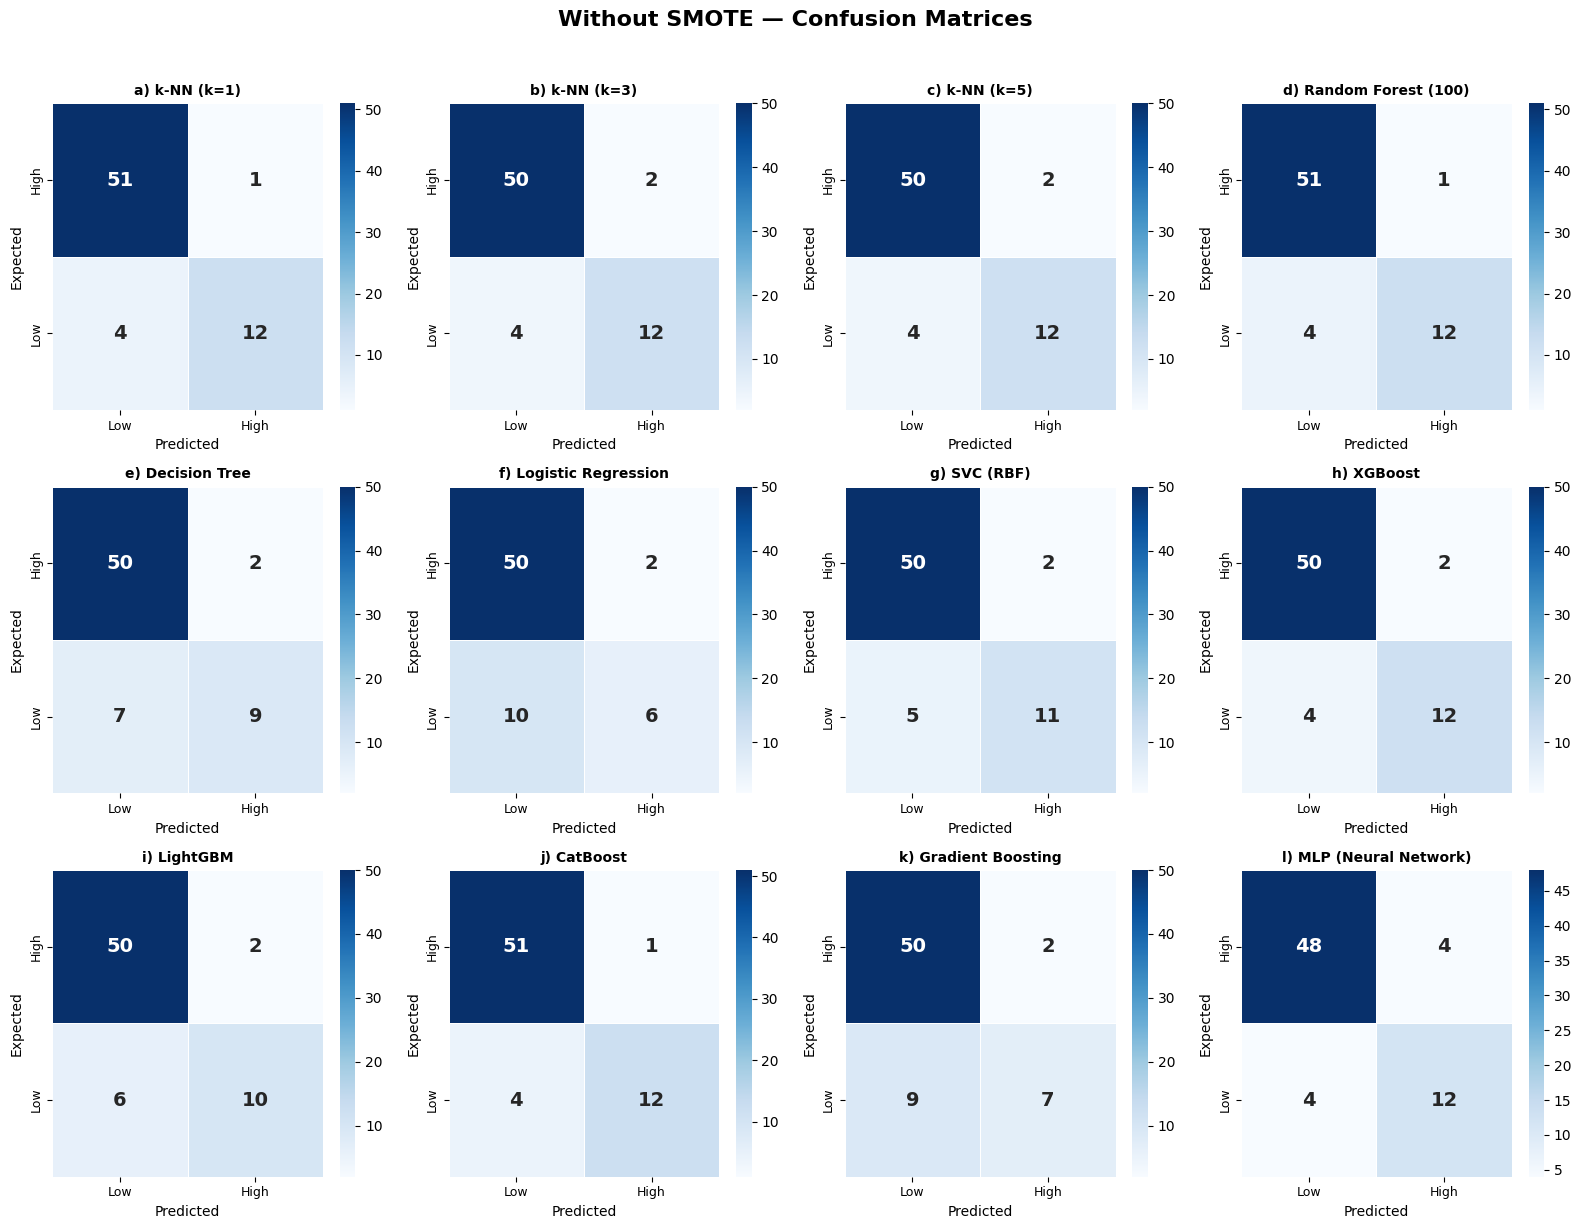

Saved: without_smote_—_confusion_matrices.png


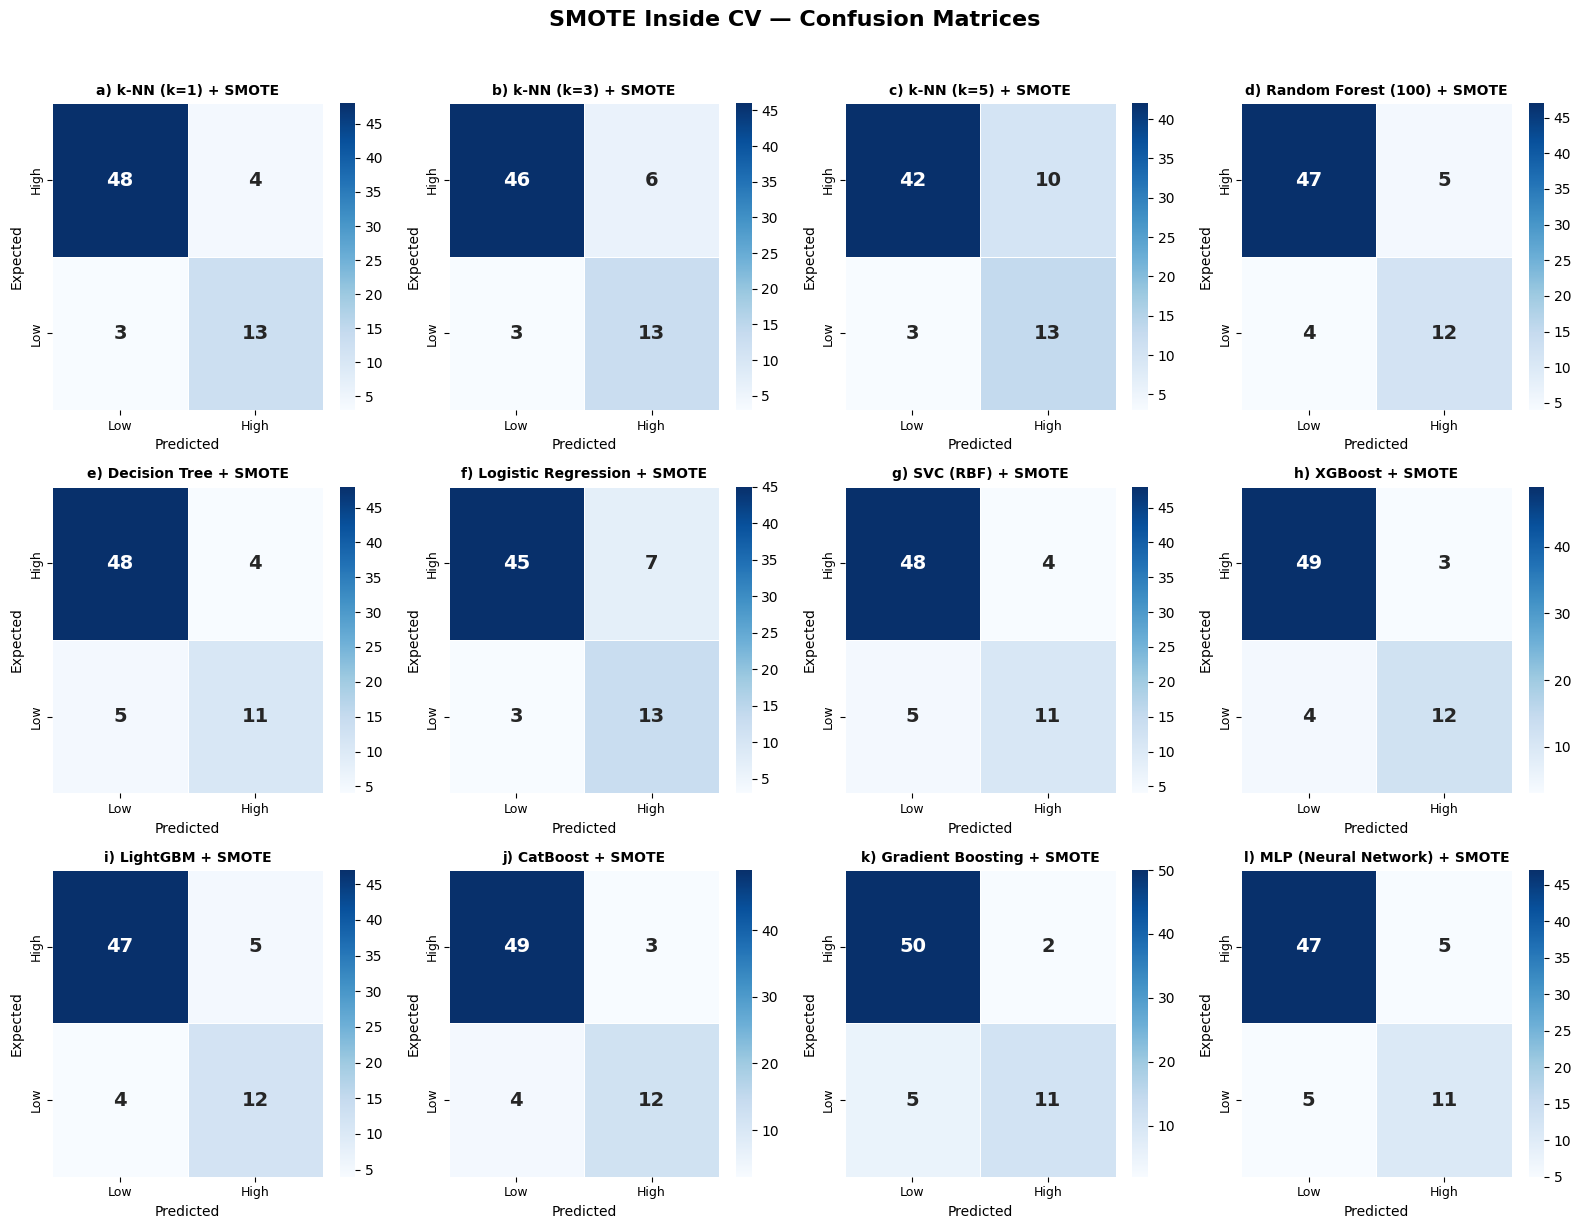

Saved: smote_inside_cv_—_confusion_matrices.png


In [ ]:
def plot_confusion_matrix_grid(results_list, title_prefix=''):
    """
    Plot a grid of confusion matrices matching the reference style.
    """
    results_filtered = [r for r in results_list if 'ZeroR' not in r['name']]

    n_models = len(results_filtered)
    n_cols = 4
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(f'{title_prefix}Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)

    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    panel_labels = 'abcdefghijklmnopqrstuvwxyz'

    for idx, r in enumerate(results_filtered):
        ax = axes_flat[idx]
        cm = r['confusion_matrix']

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Low', 'High'], yticklabels=['High', 'Low'],
                    ax=ax, cbar=True, annot_kws={'size': 14, 'fontweight': 'bold'},
                    linewidths=0.5, linecolor='white')

        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Expected', fontsize=10)
        ax.set_title(f"{panel_labels[idx]}) {r['name']}", fontsize=10, fontweight='bold')
        ax.tick_params(axis='both', labelsize=9)

    for idx in range(n_models, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.tight_layout()
    filename = f'{title_prefix.strip().replace(" ", "_").lower() if title_prefix else "original"}_confusion_matrices.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


plot_confusion_matrix_grid(all_results_original, title_prefix='Without SMOTE — ')
plot_confusion_matrix_grid(all_results_smote, title_prefix='SMOTE Inside CV — ')

## 10. Feature Importance Analysis

**Same as `zif8_ml_analysis.py`:** Mutual Information, Random Forest, Decision Tree importance.

FEATURE IMPORTANCE ANALYSIS

Feature Importance Scores:
------------------------------------------------------------
    Feature  Mutual_Information  Random_Forest  Decision_Tree  Mean_Rank
   Duration            0.103982       0.356733       0.355178   1.333333
  Solvent_1            0.152097       0.166552       0.133494   3.000000
      Ratio            0.019133       0.230133       0.306036   3.000000
Temperature            0.061412       0.220326       0.205292   3.333333
  Solvent_2            0.090281       0.026257       0.000000   4.333333

✅ Feature importance saved to feature_importance.csv


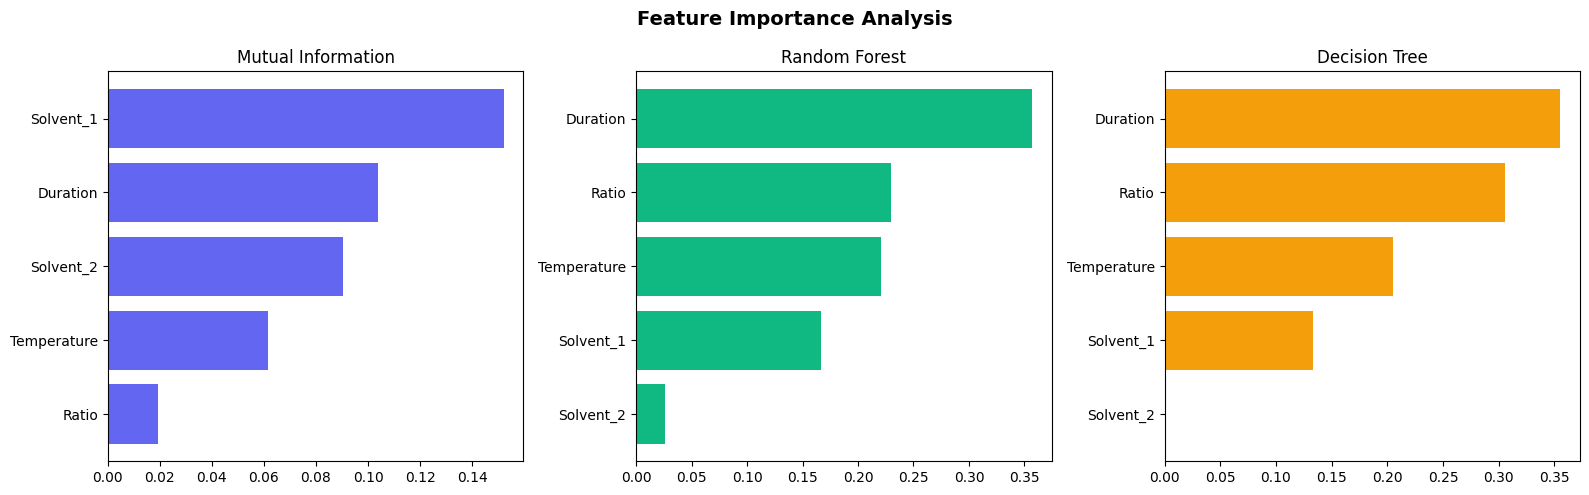

Saved: feature_importance.png


In [ ]:
print('=' * 60)
print('FEATURE IMPORTANCE ANALYSIS')
print('=' * 60)

mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)

rf_fi = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_fi.fit(X, y)
rf_importance = rf_fi.feature_importances_

dt_fi = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_fi.fit(X, y)
dt_importance = dt_fi.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mutual_Information': mi_scores,
    'Random_Forest': rf_importance,
    'Decision_Tree': dt_importance
})

for col in ['Mutual_Information', 'Random_Forest', 'Decision_Tree']:
    importance_df[f'{col}_rank'] = importance_df[col].rank(ascending=False)

importance_df['Mean_Rank'] = importance_df[[c for c in importance_df.columns if 'rank' in c]].mean(axis=1)
importance_df = importance_df.sort_values('Mean_Rank')

print('\nFeature Importance Scores:')
print('-' * 60)
print(importance_df[['Feature', 'Mutual_Information', 'Random_Forest', 'Decision_Tree', 'Mean_Rank']].to_string(index=False))

importance_df.to_csv('feature_importance.csv', index=False)
print('\n✅ Feature importance saved to feature_importance.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

imp_sorted = importance_df.sort_values('Mutual_Information', ascending=True)
axes[0].barh(imp_sorted['Feature'], imp_sorted['Mutual_Information'], color='#6366f1')
axes[0].set_title('Mutual Information', fontsize=12)

imp_sorted = importance_df.sort_values('Random_Forest', ascending=True)
axes[1].barh(imp_sorted['Feature'], imp_sorted['Random_Forest'], color='#10b981')
axes[1].set_title('Random Forest', fontsize=12)

imp_sorted = importance_df.sort_values('Decision_Tree', ascending=True)
axes[2].barh(imp_sorted['Feature'], imp_sorted['Decision_Tree'], color='#f59e0b')
axes[2].set_title('Decision Tree', fontsize=12)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## 11. Decision Tree Visualization

**Same as `zif8_ml_analysis.py`:** Pruned tree with `max_depth=4`, `min_samples_leaf=2`.

DECISION TREE ANALYSIS


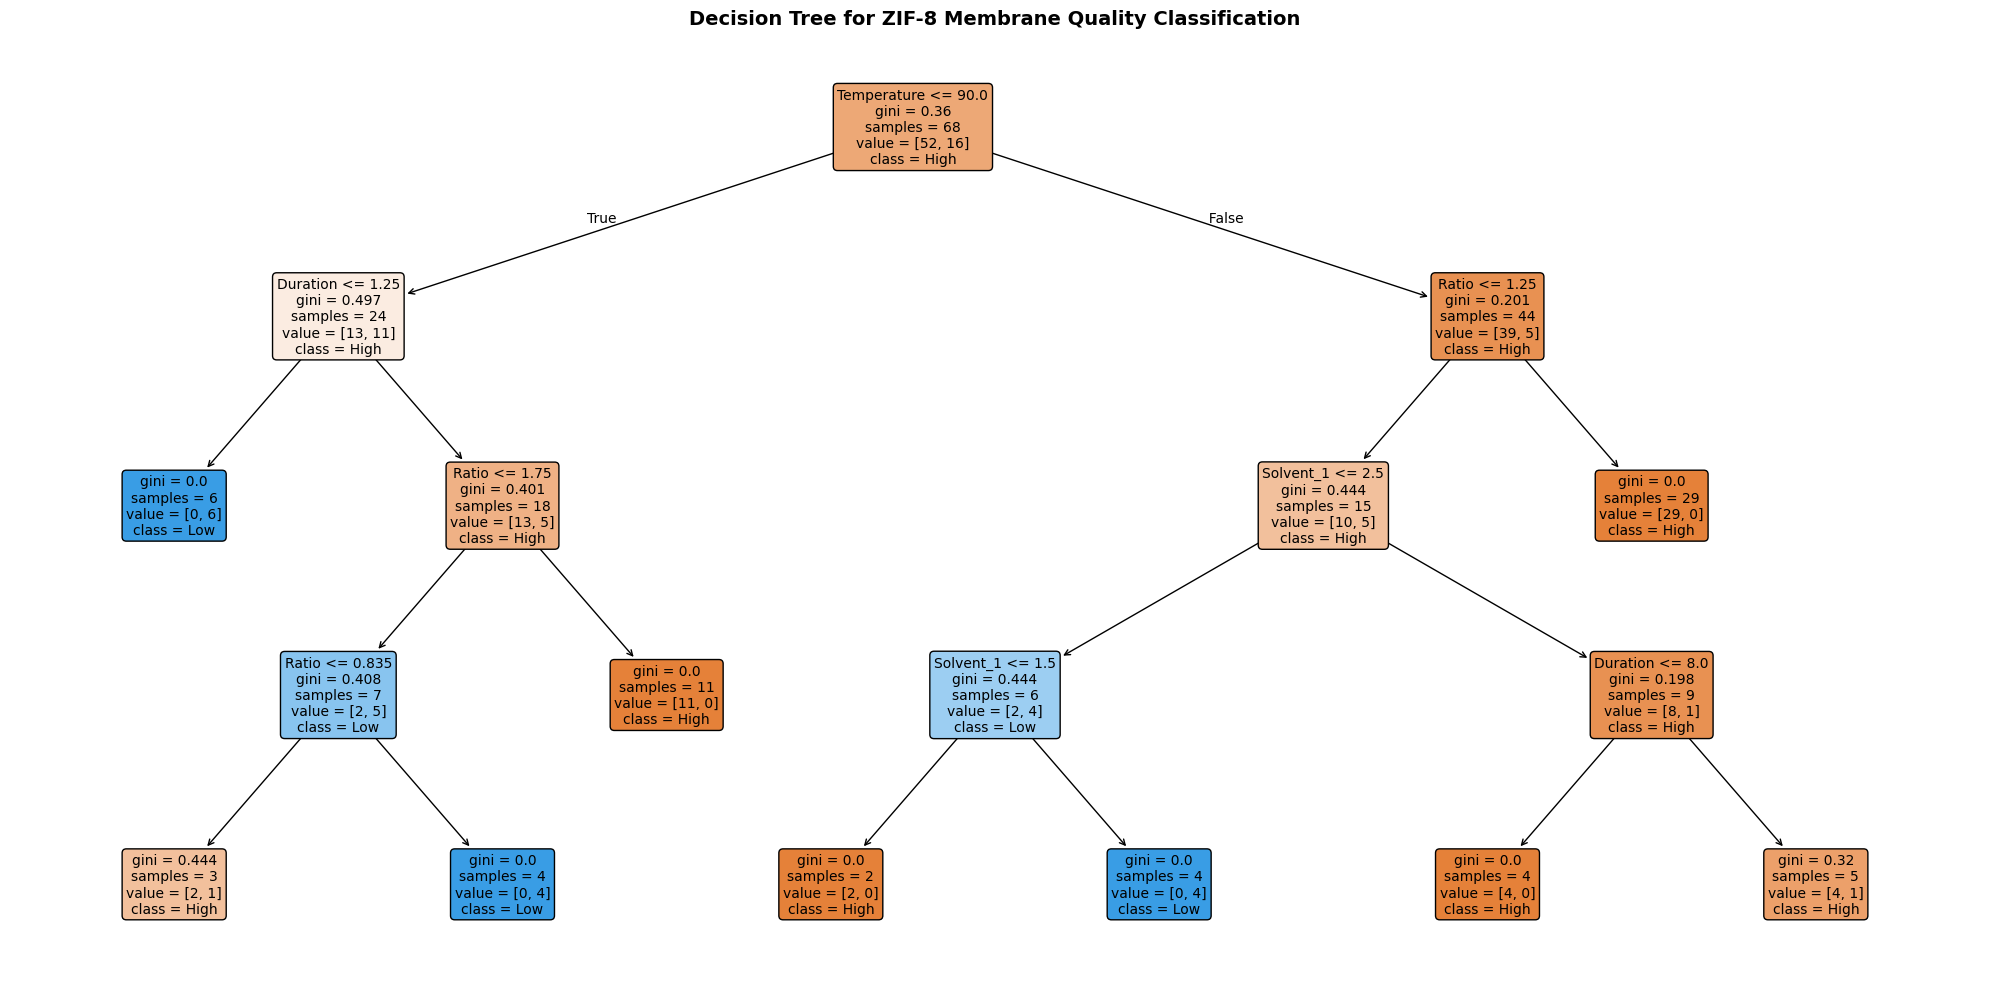


Decision Tree Structure:
  Number of leaves: 9
  Max depth: 4

✅ Saved: decision_tree.png, decision_tree.pdf


In [ ]:
print('=' * 60)
print('DECISION TREE ANALYSIS')
print('=' * 60)

dt_viz = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
dt_viz.fit(X, y)

class_names = encoders['Quality'].classes_

plt.figure(figsize=(20, 10))
plot_tree(dt_viz,
          feature_names=feature_cols,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree for ZIF-8 Membrane Quality Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
plt.savefig('decision_tree.pdf', bbox_inches='tight')
plt.show()

print(f'\nDecision Tree Structure:')
print(f'  Number of leaves: {dt_viz.get_n_leaves()}')
print(f'  Max depth: {dt_viz.get_depth()}')
print('\n✅ Saved: decision_tree.png, decision_tree.pdf')

## 12. Final Summary

In [ ]:
print('=' * 60)
print('ANALYSIS COMPLETE')
print('=' * 60)

print(f'\nModels evaluated: {len(all_results_original)} (without SMOTE) + {len(all_results_smote)} (SMOTE inside CV)')

print('\n--- Top 5 Models (Without SMOTE, by Accuracy) ---')
top5 = df_original.sort_values('Accuracy (%)', ascending=False).head(5)
print(top5[['Classifier', 'Accuracy (%)', 'Kappa', 'Recall Low (%)', 'ROC-AUC', 'R2']].to_string(index=False))

print('\n--- Top 5 Models (SMOTE Inside CV, by Accuracy) ---')
top5_smote = df_smote.sort_values('Accuracy (%)', ascending=False).head(5)
print(top5_smote[['Classifier', 'Accuracy (%)', 'Kappa', 'Recall Low (%)', 'ROC-AUC', 'R2']].to_string(index=False))

print('\nOutput files generated:')
print('  - zif8_smote_inside_cv_comparison.csv')
print('  - feature_importance.csv')
print('  - without_smote_4panel_comparison.png')
print('  - smote_inside_cv_4panel_comparison.png')
print('  - without_smote_confusion_matrices.png')
print('  - smote_inside_cv_confusion_matrices.png')
print('  - feature_importance.png')
print('  - decision_tree.png / .pdf')

ANALYSIS COMPLETE

Models evaluated: 13 (without SMOTE) + 13 (SMOTE inside CV)

--- Top 5 Models (Without SMOTE, by Accuracy) ---
         Classifier  Accuracy (%)  Kappa  Recall Low (%)  ROC-AUC    R2
         k-NN (k=1)         92.65  0.781            75.0    0.865 0.591
Random Forest (100)         92.65  0.781            75.0    0.889 0.522
           CatBoost         92.65  0.781            75.0    0.897 0.567
         k-NN (k=5)         91.18  0.744            75.0    0.900 0.598
         k-NN (k=3)         91.18  0.744            75.0    0.837 0.455

--- Top 5 Models (SMOTE Inside CV, by Accuracy) ---
               Classifier  Accuracy (%)  Kappa  Recall Low (%)  ROC-AUC    R2
       k-NN (k=1) + SMOTE         89.71  0.720            81.2    0.868 0.428
         CatBoost + SMOTE         89.71  0.708            75.0    0.903 0.538
Gradient Boosting + SMOTE         89.71  0.694            68.8    0.855 0.474
          XGBoost + SMOTE         89.71  0.708            75.0    0.880 0